## Results Analysis — Black-Box Modelling of Multiband Saturation

Here we present the results of our proposed models. Training and validation losses are plotted and some comparisons are made between the target and the predicted outputs.

## Cell 1 — Imports

In [ ]:
import os
import json
import time
import torch
import librosa
import torchaudio
import numpy as np
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
import torchaudio.functional as F
import torchaudio.transforms as T

plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.titleweight': 'normal',
    'axes.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18,
})

print("All libraries imported!")

All libraries imported!


In [2]:
# Check if CUDA is available
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
DEVICE = str(device)
print(f"Using device = {torch.get_default_device()}")

print(f"Pytorch version: {torch.__version__}")
print(f"Torchaudio version: {torchaudio.__version__}")

Using device = cpu
Pytorch version: 2.11.0+cpu
Torchaudio version: 2.11.0+cpu


## Cell 2 - Configuration

In [ ]:
# PATHS
CLEAN_DIR = r"Path\to\your\diretory\Dataset\clean"
SAT_DIR   = r"Path\to\your\diretory\Dataset\saturated"
RESULTS_DIR   = r"Path\to\your\diretory\Results\Results_H96" # from LSTM with hidden size 96
os.makedirs(RESULTS_DIR, exist_ok=True)

# Audio
SAMPLE_RATE   = 44100
CHUNK_SAMPLES = 8192                         # ~186ms a 44.1kHz — tamanho de cada frame de treino

INIT_LEN      = 0
VALIDATION_F  = 2

## Cell 3 - JSON Extraction

In [4]:
# Open JSON file with results summary (if exists) to append new results
results_summary_path = os.path.join(RESULTS_DIR, 'training_history.json')

with open(results_summary_path, 'r') as f:
    results_summary = json.load(f) if os.path.exists(results_summary_path) else print("No existing training_history.json found, starting fresh.")
    
metrics = ['train_losses', 'val_losses', 'esr_losses', 'dc_losses', 'mrstft_losses']
names = ['Train Losses', 'Validation Losses', 'ESR Losses', 'DC Losses', 'MRSTFT Losses']

for metric in metrics:
    if metric not in results_summary:
        print(f"No existing {metric} found.")
        results_summary[metric] = []

print("\nDATA:")

for i, metric in enumerate(metrics):
    print(f"{names[i]}: {len(results_summary[metric])} entries")

train_losses  = results_summary.get('train_losses', [])
train_epochs  = len(train_losses)
val_losses    = results_summary.get('val_losses', [])
val_epochs    = len(val_losses)
esr_losses    = results_summary.get('esr_losses', [])
dc_losses     = results_summary.get('dc_losses', [])
mrstft_losses = results_summary.get('mrstft_losses', [])


DATA:
Train Losses: 1000 entries
Validation Losses: 500 entries
ESR Losses: 500 entries
DC Losses: 500 entries
MRSTFT Losses: 500 entries


## Cell 4 - Loss Plots

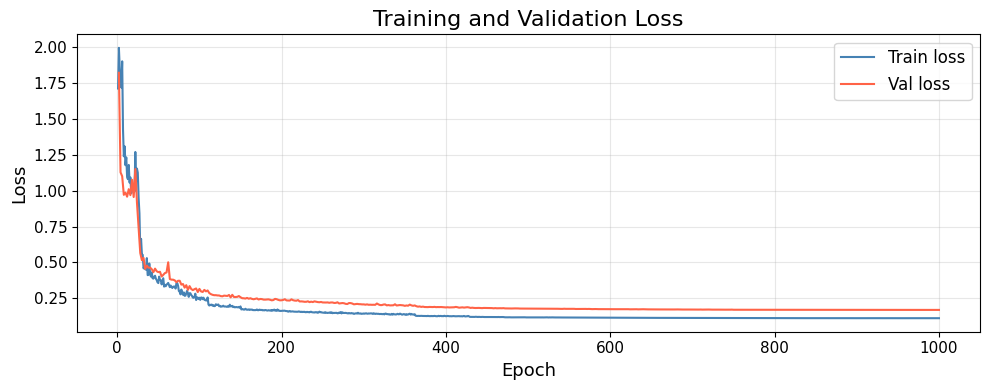

Plot saved as fig2_Training_&_Validation Loss.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train loss', color='steelblue')

if val_losses:
    # As validações ocorrem apenas de VALIDATION_F em VALIDATION_F epochs
    val_epochs = [i * VALIDATION_F for i in range(1, len(val_losses) + 1)]
    ax.plot(val_epochs, val_losses, label='Val loss', color='tomato', markersize=4)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
# ax.set_xlim(1, 200)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_Training_&_Validation Loss.png'), dpi=150)
plt.show()
print(f"Plot saved as fig2_Training_&_Validation Loss.png")

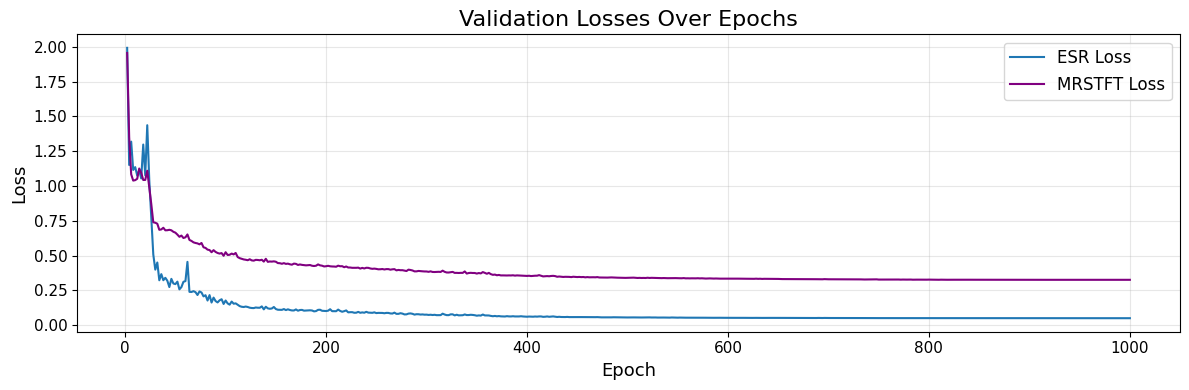

Plot saved as fig1_Validation_Losses.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(range(VALIDATION_F, VALIDATION_F * len(esr_losses) + 1, VALIDATION_F), esr_losses, label='ESR Loss')
ax.plot(range(VALIDATION_F, VALIDATION_F * len(mrstft_losses) + 1, VALIDATION_F), mrstft_losses, label='MRSTFT Loss', color='purple')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(fontsize=12, loc='upper right')
ax.set_title('Validation Losses Over Epochs')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_Validation_Losses.png'), dpi=150)
plt.show()
print(f"Plot saved as fig1_Validation_Losses.png")

## Cell 5 - Output Audio Comparison

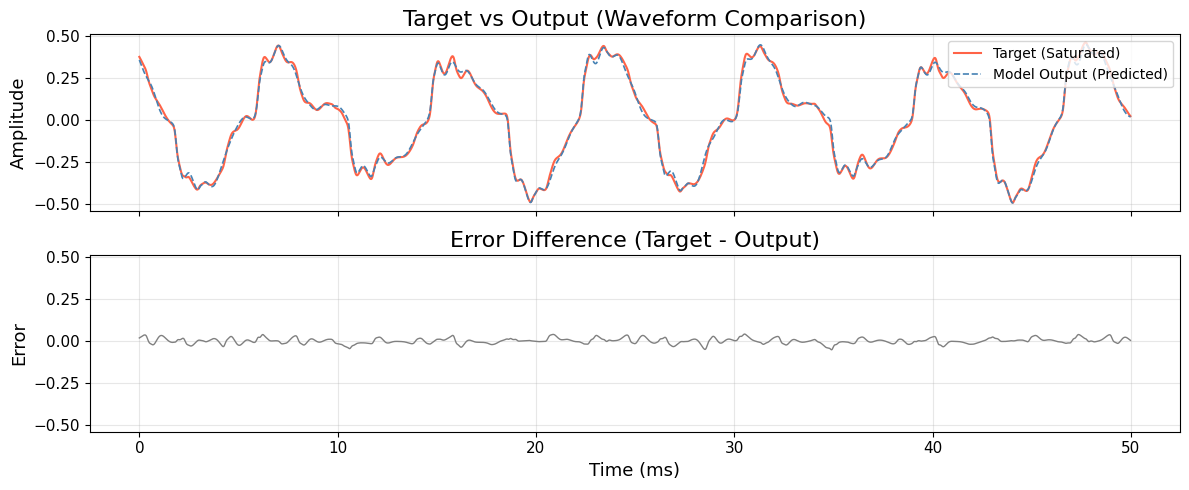

Plot saved as fig3_Waveform_Comparison.png


In [7]:
sat_file = Path(SAT_DIR + "\ST\\") / "BS_1_EQ_1_ST_NO_1_0_saturated.wav"
predicted_file = os.path.join(RESULTS_DIR, "model_output.wav")

# Load both target and predicted audio files
target_tensor, sr = torchaudio.load(str(sat_file))
predicted_tensor, sr_pred = torchaudio.load(str(predicted_file))

warm_up = INIT_LEN
target_np = target_tensor.squeeze().numpy()[warm_up:]
output_np = predicted_tensor.squeeze().numpy()

min_len = min(len(target_np), len(output_np))
target_np = target_np[:min_len]
output_np = output_np[:min_len]

n_show  = int(0.05 * SAMPLE_RATE)

mid = max(0, min_len // 2 - n_show // 2)
t   = np.arange(n_show) / SAMPLE_RATE * 1000

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t, target_np[mid:mid + n_show], color='tomato', linewidth=1.5, label='Target (Saturated)')
axes[0].plot(t, output_np[mid:mid + n_show], color='steelblue', linewidth=1.2, linestyle='dashed', label='Model Output (Predicted)')
ymin, ymax = axes[0].get_ylim()
axes[0].set_ylim(ymin, ymax)
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].set_title('Target vs Output (Waveform Comparison)')
axes[0].grid(True, alpha=0.3)

error = target_np[mid:mid + n_show] - output_np[mid:mid + n_show]
axes[1].plot(t, error, color='gray', linewidth=1)
axes[1].set_ylim(ymin, ymax)
axes[1].set_ylabel('Error')
axes[1].set_xlabel('Time (ms)')
axes[1].set_title('Error Difference (Target - Output)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_Waveform_Comparison.png'), dpi=150)
plt.show()
print(f"Plot saved as fig3_Waveform_Comparison.png")

## Cell 6 - Spectrogram Comparison

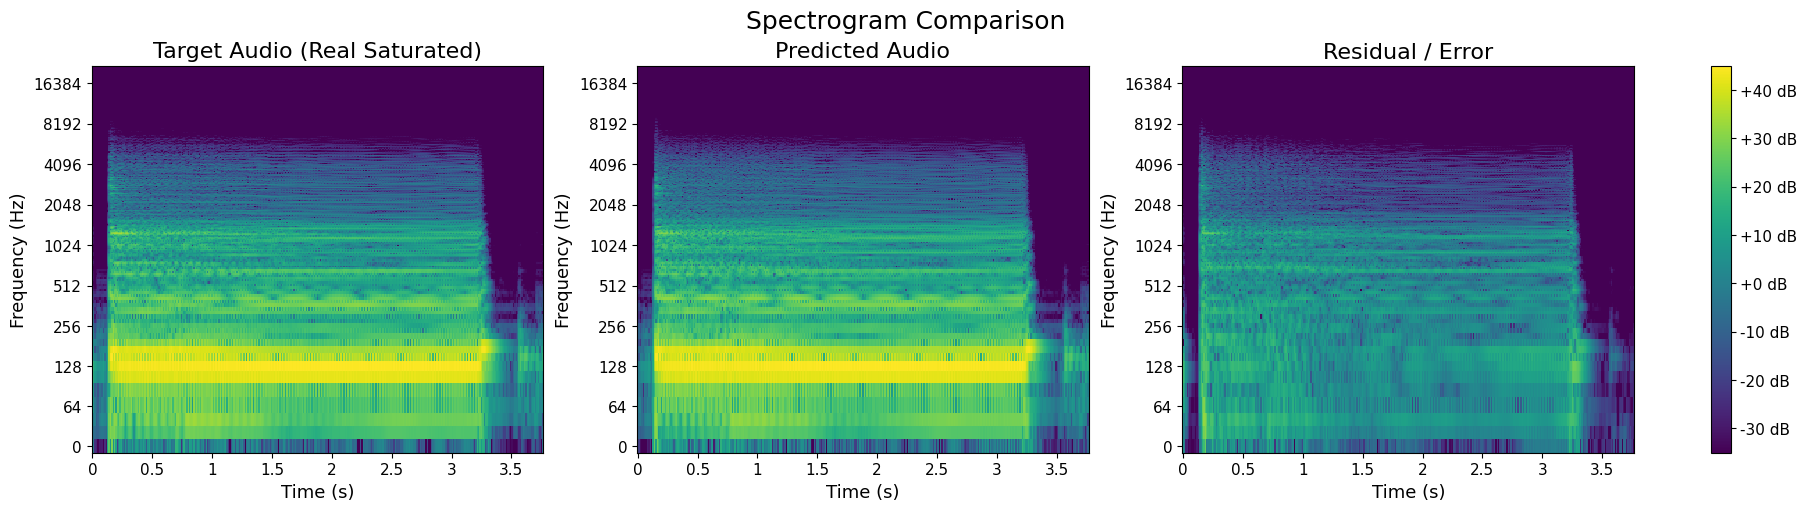

Plot saved as fig4_Spectrogram_Comparison.png


In [8]:
def plot_spectrogram(ax, waveform, sr, title, vmin=None, vmax=None):
    if isinstance(waveform, np.ndarray):
        waveform = torch.from_numpy(waveform)
    
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)
        
    spectrogram = T.Spectrogram(
        n_fft=2048,
        hop_length=512,
        power=None,
        center=True,
        pad_mode="reflect",
    )

    spec_complex = spectrogram(waveform)
    mag = spec_complex.abs()
    db = T.AmplitudeToDB(stype="magnitude", top_db=80)(mag)
    db_np = db[0].cpu().numpy()

    # Log frequency axis for better audio readability
    img = librosa.display.specshow(
        db_np,
        sr=sr,
        hop_length=512,
        x_axis="time",
        y_axis="log",
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    return img, db_np


fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

residual = target_np - output_np

img_target, target_db = plot_spectrogram(axs[0], target_np, SAMPLE_RATE, "Target Audio (Real Saturated)")

ref_vmax = target_db.max()
ref_vmin = target_db.min()

img_pred, _ = plot_spectrogram(axs[1], output_np, SAMPLE_RATE, "Predicted Audio", vmin=ref_vmin, vmax=ref_vmax)

# Residual
img_res, _ = plot_spectrogram(axs[2], residual, SAMPLE_RATE, "Residual / Error", vmin=ref_vmin, vmax=ref_vmax)

fig.colorbar(img_target, ax=axs, format="%+2.0f dB")
fig.suptitle("Spectrogram Comparison", fontsize=18)

plt.savefig(os.path.join(RESULTS_DIR, 'fig4_Spectrogram_Comparison.png'), dpi=150, bbox_inches="tight")
plt.show()

print(f"Plot saved as fig4_Spectrogram_Comparison.png")

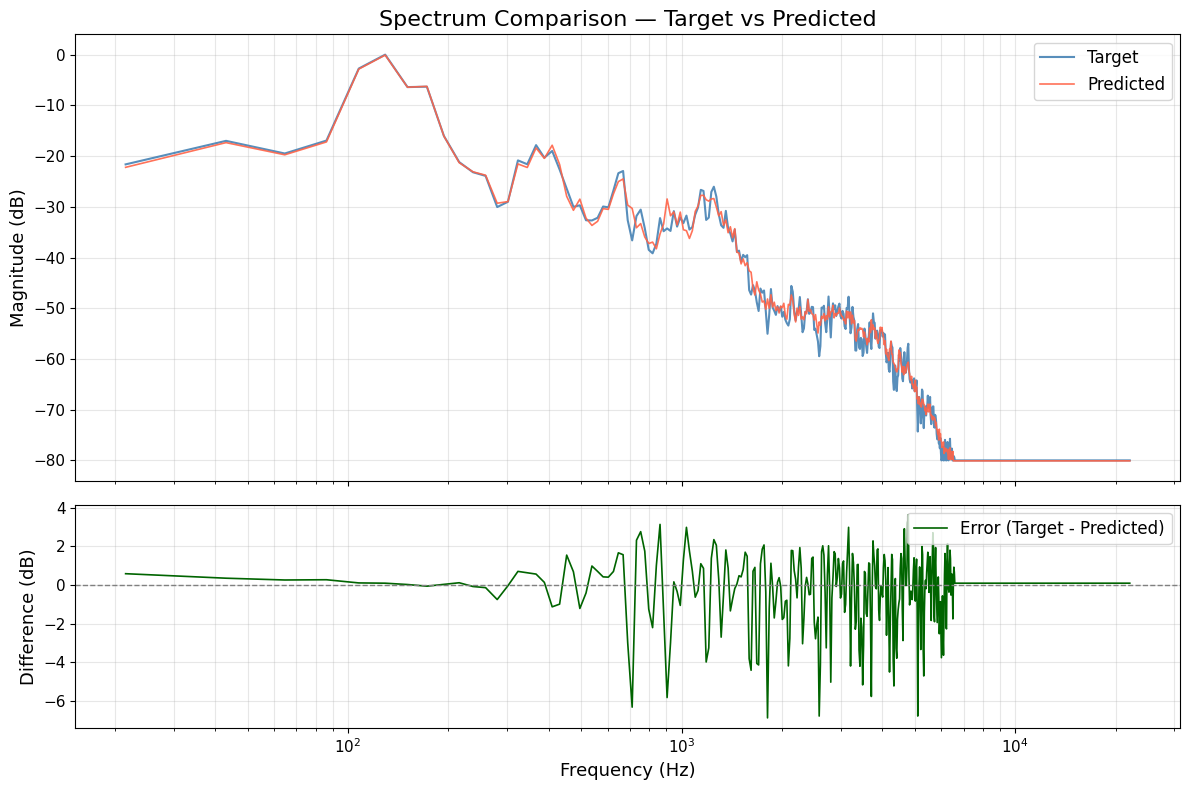

Plot saved as fig5_Spectrum_Comparison.png


In [9]:
freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)

sample_target, _ = librosa.load(sat_file, sr=sr, mono=True)
sample_predicted, _ = librosa.load(predicted_file, sr=sr, mono=True)

mag_target = np.abs(librosa.stft(sample_target, n_fft=2048)).mean(axis=1)
mag_predicted = np.abs(librosa.stft(sample_predicted, n_fft=2048)).mean(axis=1)

ref_val = mag_target.max()
target_db = librosa.amplitude_to_db(mag_target, ref=ref_val)
predicted_db = librosa.amplitude_to_db(mag_predicted, ref=ref_val)

error_db = target_db - predicted_db

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].semilogx(freqs[1:], target_db[1:], color="steelblue", label="Target", linewidth=1.5, alpha=0.9)
axes[0].semilogx(freqs[1:], predicted_db[1:], color="tomato", label="Predicted", linewidth=1.2, alpha=0.9)
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_title("Spectrum Comparison — Target vs Predicted")
axes[0].grid(True, alpha=0.3, which="both")
axes[0].legend(loc="upper right")

# Residual
axes[1].semilogx(freqs[1:], error_db[1:], color="darkgreen", label="Error (Target - Predicted)", linewidth=1.2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Difference (dB)")
axes[1].grid(True, alpha=0.3, which="both")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig5_Spectrum_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Plot saved as fig5_Spectrum_Comparison.png")